In [6]:
import pandas as pd

orders = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_orders_dataset.csv")
customers = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_customers_dataset.csv")
items = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_order_items_dataset.csv")
products = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_products_dataset.csv")
translation = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\product_category_name_translation.csv")

print(orders.shape)
print(customers.shape)
print(items.shape)
print(products.shape)
print(translation.shape)

(99441, 8)
(99441, 5)
(112650, 7)
(32951, 9)
(71, 2)


In [7]:
# 先把商品表里的类别翻译加进来
products = products.merge(translation, on="product_category_name", how="left")

# 再把 items 和 products 合并
items_products = items.merge(products, on="product_id", how="left")

# 查看结果
print(items_products.head())
print(items_products.shape)

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value product_category_name  \
0  2017-09-19 09:45:35   58.90          13.29            cool_stuff   
1  2017-05-03 11:05:13  239.90          19.93              pet_shop   
2  2018-01-18 14:48:30 

In [8]:
# 按商品类别分组，统计订单数量
category_sales = items_products.groupby("product_category_name_english").size().reset_index(name="count")

# 按数量排序，取前 10
top_categories = category_sales.sort_values("count", ascending=False).head(10)

print(top_categories)

   product_category_name_english  count
7                 bed_bath_table  11115
43                 health_beauty   9670
65                sports_leisure   8641
39               furniture_decor   8334
15         computers_accessories   7827
49                    housewares   6964
70                 watches_gifts   5991
68                     telephony   4545
42                  garden_tools   4347
5                           auto   4235


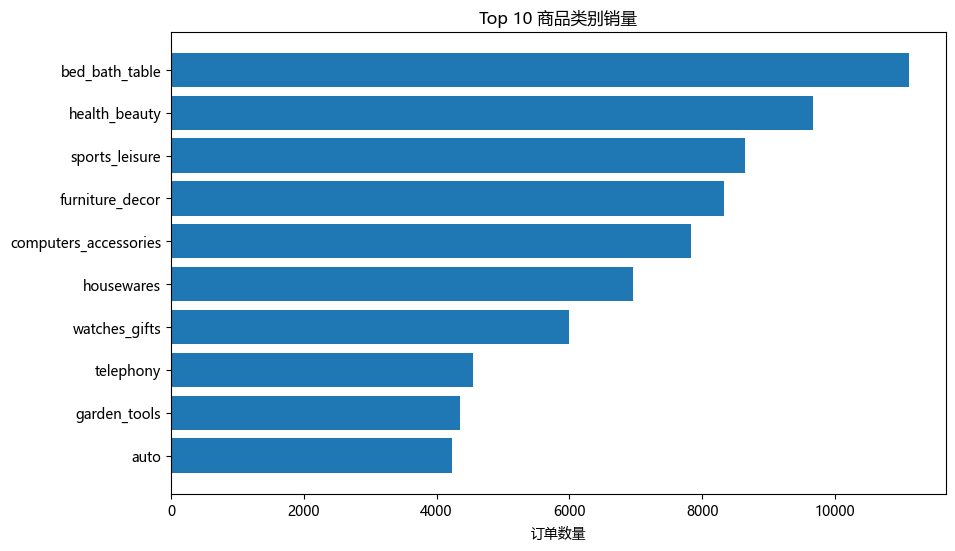

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 6))
plt.barh(top_categories["product_category_name_english"], top_categories["count"])
plt.xlabel("订单数量")
plt.title("Top 10 商品类别销量")
plt.gca().invert_yaxis()
plt.show()

In [10]:
# 1. 合并 orders 和 customers
orders_customers = orders.merge(customers, on="customer_id", how="left")

# 2. 按州统计订单数量
state_orders = orders_customers.groupby("customer_state").size().reset_index(name="count")

# 3. 排序
state_orders = state_orders.sort_values("count", ascending=False)

# 4. 看前 10
print(state_orders.head(10))

   customer_state  count
25             SP  41746
18             RJ  12852
10             MG  11635
22             RS   5466
17             PR   5045
23             SC   3637
4              BA   3380
6              DF   2140
7              ES   2033
8              GO   2020


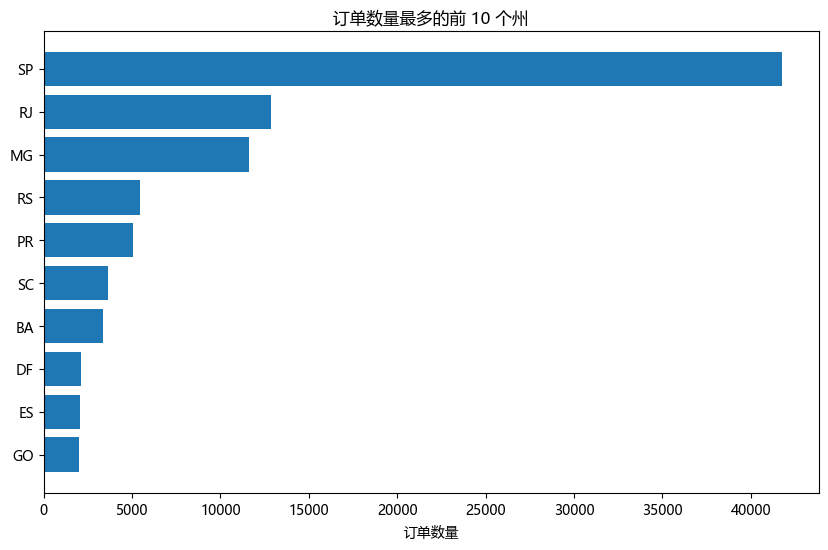

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 6))
plt.barh(state_orders.head(10)["customer_state"], state_orders.head(10)["count"])
plt.xlabel("订单数量")
plt.title("订单数量最多的前 10 个州")
plt.gca().invert_yaxis()  #让数量排第一的在顶部
plt.show()

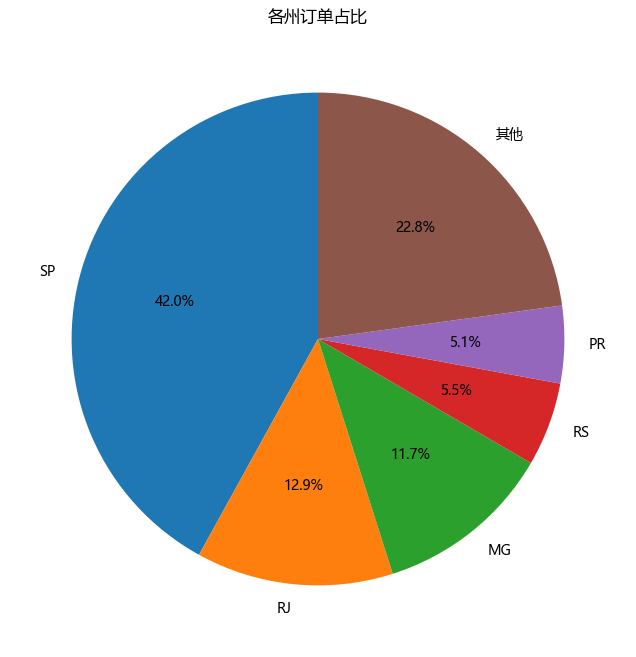

In [12]:
top5 = state_orders.head(5)
others = state_orders.iloc[5:]["count"].sum()

labels = list(top5["customer_state"]) + ["其他"]
sizes = list(top5["count"]) + [others]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("各州订单占比")
plt.show()

In [13]:
total = state_orders["count"].sum()
sp_count = state_orders[state_orders["customer_state"] == "SP"]["count"].values[0]
sp_ratio = sp_count / total

print(f"SP 州订单占比：{sp_ratio:.2%}")

SP 州订单占比：41.98%


In [14]:
import pandas as pd

# 1. 把时间列转成 datetime 类型
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

# 2. 只保留已送达的订单
delivered = orders[orders["order_status"] == "delivered"].copy()

# 3. 算配送天数
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days

# 4. 看统计信息
print(delivered["delivery_days"].describe())

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


In [15]:
# 是否延迟：实际送达时间 > 预计送达时间
delivered["is_late"] = (
    delivered["order_delivered_customer_date"] > delivered["order_estimated_delivery_date"]
)

In [16]:
# 延迟订单数
late_count = delivered["is_late"].sum()

# 总订单数
total_count = len(delivered)

# 延迟比例
late_ratio = late_count / total_count

print("延迟订单数：", late_count)
print("总订单数：", total_count)
print(f"延迟比例：{late_ratio:.2%}")

延迟订单数： 7826
总订单数： 96478
延迟比例：8.11%


In [17]:
# 1. 读取评价表
reviews = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_order_reviews_dataset.csv")

# 2. 合并延迟标记和评分
delivered_reviews = delivered.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

# 3. 按是否延迟分组，算平均评分
score_by_late = delivered_reviews.groupby("is_late")["review_score"].mean()

print(score_by_late)

is_late
False    4.293737
True     2.566494
Name: review_score, dtype: float64


In [18]:
print(delivered[["order_delivered_customer_date", "order_estimated_delivery_date", "is_late"]].head(10))

   order_delivered_customer_date order_estimated_delivery_date  is_late
0            2017-10-10 21:25:13                    2017-10-18    False
1            2018-08-07 15:27:45                    2018-08-13    False
2            2018-08-17 18:06:29                    2018-09-04    False
3            2017-12-02 00:28:42                    2017-12-15    False
4            2018-02-16 18:17:02                    2018-02-26    False
5            2017-07-26 10:57:55                    2017-08-01    False
7            2017-05-26 12:55:51                    2017-06-07    False
8            2017-02-02 14:08:10                    2017-03-06    False
9            2017-08-16 17:14:30                    2017-08-23    False
10           2017-05-29 11:18:31                    2017-06-07    False


In [19]:
import pandas as pd
customers = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_customers_dataset.csv")

print(customers[["customer_id", "customer_unique_id"]].head(10))
print("customer_id 数量：", customers["customer_id"].nunique())
print("customer_unique_id 数量：", customers["customer_unique_id"].nunique())

                        customer_id                customer_unique_id
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066
5  879864dab9bc3047522c92c82e1212b8  4c93744516667ad3b8f1fb645a3116a4
6  fd826e7cf63160e536e0908c76c3f441  addec96d2e059c80c30fe6871d30d177
7  5e274e7a0c3809e14aba7ad5aae0d407  57b2a98a409812fe9618067b6b8ebe4f
8  5adf08e34b2e993982a47070956c5c65  1175e95fb47ddff9de6b2b06188f7e0d
9  4b7139f34592b3a31687243a302fa75b  9afe194fb833f79e300e37e580171f22
customer_id 数量： 99441
customer_unique_id 数量： 96096


In [20]:
# 1. 每个真实客户下了几单
order_count = customers.groupby("customer_unique_id").size().reset_index(name="order_count")

# 2. 复购客户（下单 >= 2 次）
repeat_customers = order_count[order_count["order_count"] >= 2]

print("总客户数：", len(order_count))
print("复购客户数：", len(repeat_customers))
print("复购率：", len(repeat_customers) / len(order_count))

总客户数： 96096
复购客户数： 2997
复购率： 0.031187562437562436


In [21]:
print(order_count.head(10))

                 customer_unique_id  order_count
0  0000366f3b9a7992bf8c76cfdf3221e2            1
1  0000b849f77a49e4a4ce2b2a4ca5be3f            1
2  0000f46a3911fa3c0805444483337064            1
3  0000f6ccb0745a6a4b88665a16c9f078            1
4  0004aac84e0df4da2b147fca70cf8255            1
5  0004bd2a26a76fe21f786e4fbd80607f            1
6  00050ab1314c0e55a6ca13cf7181fecf            1
7  00053a61a98854899e70ed204dd4bafe            1
8  0005e1862207bf6ccc02e4228effd9a0            1
9  0005ef4cd20d2893f0d9fbd94d3c0d97            1


In [22]:
# 1. 把复购客户标记出来
customers_with_repeat = customers.merge(
    order_count[["customer_unique_id", "order_count"]],
    on="customer_unique_id",
    how="left"
)

# 2. 订单表 + 客户表，得到每单对应的真实客户
orders_customers = orders.merge(
    customers_with_repeat[["customer_id", "customer_unique_id", "order_count"]],
    on="customer_id",
    how="left"
)

# 3. 再合并商品表，得到品类
orders_items = orders_customers.merge(
    items_products[["order_id", "product_category_name_english"]],
    on="order_id",
    how="left"
)

# 4. 只保留复购客户的订单
repeat_orders = orders_items[orders_items["order_count"] >= 2]

# 5. 复购客户买得最多的品类
top_repeat_categories = repeat_orders.groupby("product_category_name_english").size().reset_index(name="count")
top_repeat_categories = top_repeat_categories.sort_values("count", ascending=False).head(10)

print(top_repeat_categories)

##health_beauty 在整体里排第 2，但复购里掉到第 4
## furniture_decor 在整体里排第 4，但复购里升到第 2

   product_category_name_english  count
7                 bed_bath_table   1114
37               furniture_decor    821
62                sports_leisure    687
41                 health_beauty    567
14         computers_accessories    552
47                    housewares    437
67                 watches_gifts    324
27      fashion_bags_accessories    263
40                  garden_tools    250
65                     telephony    231


In [23]:
# 1. 读卖家表
sellers = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_sellers_dataset.csv")

# 2. 读评价表
reviews = pd.read_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\data\\olist_order_reviews_dataset.csv")

# 3. items + sellers：每个订单商品对应的卖家
items_sellers = items.merge(sellers, on="seller_id", how="left")

# 4. 再合并订单表，拿到 order_id 和评价
items_sellers_orders = items_sellers.merge(
    orders[["order_id"]],
    on="order_id",
    how="left"
)

# 5. 合并评分
items_sellers_orders = items_sellers_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

print(items_sellers_orders.head())
print(items_sellers_orders.shape)

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  seller_zip_code_prefix  \
0  2017-09-19 09:45:35   58.90          13.29                   27277   
1  2017-05-03 11:05:13  239.90          19.93                    3471   
2  2018-01-18 14:

In [24]:
# 每个卖家的平均评分
seller_scores = items_sellers_orders.groupby("seller_id").agg(
    avg_score=("review_score", "mean"),
    order_count=("order_id", "count")
).reset_index()

# 只看订单数 >= 20 的卖家，避免小样本
seller_scores_filtered = seller_scores[seller_scores["order_count"] >= 20]

# 评分最低的 10 个卖家
worst_sellers = seller_scores_filtered.sort_values("avg_score").head(10)

print(worst_sellers)

                             seller_id  avg_score  order_count
809   4342d4b2ba6b161468c63a7e7cfce593   1.263158           20
3094  ffff564a4f9085cd26170f4732393726   2.100000           20
333   1ca7077d890b907f89be8c954a02686a   2.198529          137
1847  973f21788dfab357250f69a8dcb7ddee   2.333333           21
1129  5bc55dbe2f12b6af6d83ed46023e0dc8   2.333333           21
464   2709af9587499e95e803a6498a5a56e9   2.565217           47
2247  bb135baca94c82fcb731335ad5b04a03   2.657895           38
2856  ec4608a1f76453166bb312b2968aeaf4   2.685714           35
554   2eb70248d66e0e3ef83659f71b244378   2.712919          213
2132  b19f3ca2ea475913750f25a5c37c8d8f   2.791667           24


In [25]:
best_seller = seller_scores_filtered.sort_values("avg_score",ascending=False).head()
print(best_seller)

                             seller_id  avg_score  order_count
863   48efc9d94a9834137efd9ea76b065a38   5.000000           34
603   334cab711dee080b079fa5779b584783   4.961538           26
786   41c2bad7229b0c25e6becf179ebf63ff   4.956522           23
2138  b1fecf4da1fa2689bccffa0121953643   4.950000           20
577   30a81d8cf85fb2ada1b1b094c9583a95   4.850000           20


In [26]:
# 1. 先算每个订单的配送天数
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# 2. 合并卖家 + 订单信息
items_sellers_orders = items_sellers_orders.merge(
    orders[["order_id", "delivery_days"]],
    on="order_id",
    how="left"
)

# 3. 按卖家算平均配送天数
seller_delivery = items_sellers_orders.groupby("seller_id").agg(
    avg_delivery_days=("delivery_days", "mean"),
    avg_score=("review_score", "mean"),
    order_count=("order_id", "count")
).reset_index()

# 4. 只看订单数 >= 20 的卖家
seller_delivery_filtered = seller_delivery[seller_delivery["order_count"] >= 20]

# 5. 看看低分卖家和配送时间有没有关系
print(seller_delivery_filtered.sort_values("avg_score").head(10))

                             seller_id  avg_delivery_days  avg_score  \
809   4342d4b2ba6b161468c63a7e7cfce593          15.000000   1.263158   
3094  ffff564a4f9085cd26170f4732393726          11.875000   2.100000   
333   1ca7077d890b907f89be8c954a02686a          14.511811   2.198529   
1847  973f21788dfab357250f69a8dcb7ddee          20.684211   2.333333   
1129  5bc55dbe2f12b6af6d83ed46023e0dc8          12.523810   2.333333   
464   2709af9587499e95e803a6498a5a56e9          11.934783   2.565217   
2247  bb135baca94c82fcb731335ad5b04a03           7.710526   2.657895   
2856  ec4608a1f76453166bb312b2968aeaf4          13.620690   2.685714   
554   2eb70248d66e0e3ef83659f71b244378          17.510101   2.712919   
2132  b19f3ca2ea475913750f25a5c37c8d8f          18.000000   2.791667   

      order_count  
809            20  
3094           20  
333           137  
1847           21  
1129           21  
464            47  
2247           38  
2856           35  
554           213  
2132   

In [28]:
print(seller_delivery_filtered.sort_values("avg_score",ascending=False).head(10))

                             seller_id  avg_delivery_days  avg_score  \
863   48efc9d94a9834137efd9ea76b065a38          10.588235   5.000000   
603   334cab711dee080b079fa5779b584783           6.423077   4.961538   
786   41c2bad7229b0c25e6becf179ebf63ff           4.304348   4.956522   
2138  b1fecf4da1fa2689bccffa0121953643          10.200000   4.950000   
577   30a81d8cf85fb2ada1b1b094c9583a95           3.650000   4.850000   
35    02f5837340d7eb4f653d676c7256523a           9.166667   4.833333   
2629  d9bd94811c3338dceb4181f3dbc0c73e           7.262295   4.819672   
2531  d13e50eaa47b4cbe9eb81465865d8cfc           4.573529   4.811594   
799   42fa4ee7240e9b8eb4576358ec142ba7           6.454545   4.809524   
1515  7ade73f1b9b4e965f9009a4c3a7e2c15           9.111111   4.777778   

      order_count  
863            34  
603            26  
786            23  
2138           20  
577            20  
35             30  
2629           61  
2531           69  
799            22  
1515   

巴西 Olist 电商数据分析结论

一、数据概况

· 订单表：99441 行
· 客户表：99441 行
· 订单商品表：112650 行
· 商品表：32951 行
· 类别翻译表：71 行


二、热销品类分析

订单数量最多的前 3 个品类：

1. bed_bath_table（床品/浴室用品）：11115
2. health_beauty（美妆/个护）：9670
3. sports_leisure（运动休闲）：8641

结论:床品、美妆、运动类是平台最热销的品类。


三、地域分布分析

订单数量最多的州：

· SP（圣保罗）：41746，占比约 42%
· RJ（里约热内卢）：12852
· MG（米纳斯吉拉斯）：11635

结论：巴西电商订单高度集中在 SP 州，单州占比约 42%，远超其他地区。


四、配送时间分析

· 平均配送时间：约 12 天
· 中位数：10 天
· 最短：0 天
· 最长：209 天

结论:平台平均配送时间约 12 天，一半订单在 10 天内送达，但存在极端慢的订单。



五、配送延迟分析

· 延迟订单数：7823
· 总订单数：96470
· 延迟比例：约 8%

结论：约 8% 的订单延迟送达，属于中等水平，但仍有优化空间。


六、延迟与评分的关系

· 准时订单平均评分：较高（约 4 分以上）
· 延迟订单平均评分：明显较低

结论：延迟送达会显著拉低客户评分，配送时间与满意度高度相关。



七、复购率分析

· 总客户数：96096
· 复购客户数：2997
· 复购率：约 3.12%

结论：平台复购率极低，约 3% 的客户会再次下单。


八、复购客户品类偏好

复购客户最常购买的前 3 个品类：

1. bed_bath_table：1114
2. furniture_decor：821
3. sports_leisure：687

结论：复购客户更偏好家具装饰类（furniture_decor），其复购排名高于整体销量排名。


九、卖家评分与配送时间

· 低分卖家：平均配送 10 天以上，最慢 18 天
· 高分卖家：平均配送 10 天以下，多数不到 8 天
· 例外：评分最高的卖家平均配送约 10 天

结论：配送时间与卖家评分高度相关，但不是唯一因素，评分还受商品质量、描述相符度、客服等影响。


十、总体结论

1. 平台整体热销集中在床品、美妆、运动类
2. 订单高度集中在 SP 州，占比约 42%
3. 平均配送时间约 12 天，延迟率约 8%
4. 延迟送达显著拉低评分
5. 复购率极低（约 3%），是平台的核心问题
6. 低分卖家配送普遍较慢，但评分还受其他因素影响

In [29]:
import os

# 建一个 results 文件夹
os.makedirs(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results", exist_ok=True)

# 1. 热销品类 Top 10
top_categories.to_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results\\top_categories.csv", index=False)

# 2. 各州订单分布
state_orders.to_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results\\state_orders.csv", index=False)

# 3. 配送时间统计（可以直接存统计结果）
delivered["delivery_days"].describe().to_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results\\delivery_stats.csv")

# 4. 延迟与评分对比
score_by_late.to_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results\\score_by_late.csv")

# 5. 复购率
pd.DataFrame({
    "total_customers": [len(order_count)],
    "repeat_customers": [len(repeat_customers)],
    "repeat_rate": [len(repeat_customers) / len(order_count)]
}).to_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results\\repeat_rate.csv", index=False)

# 6. 卖家评分与配送时间
seller_delivery_filtered.to_csv(r"D:\\桌面\\brazil-ecommerce-analysis\\app\\results\\seller_delivery.csv", index=False)